# Observing Phenometrics in Madagascar using MODIS data
---
**Summary**
This script demonstrates how to access and use Moderate Resolution Imaging Spectroradiometer (MODIS) NDVI, EVI, QA, and DOY products through Earthdata. Specifically, the code searches for products in the bounds of the Military Grid Reference System (MGRS) tile, 39KUA, in order to compare its results with an HLS script that examines the same region.

**What is MODIS data?**
The Moderate Resolution Imaging Spectroradiometer (MODIS) continually collects data in 36 spectral channels with global coverage every 1 to 2 days. Its exceptionally broad spectral range enables MODIS data to be used in studies across numerous disciplines, including vegetative health, changes in land cover and land use, oceans and ocean biology, sea surface temperature, and cloud analysis. It also is used extensively for monitoring fires and natural hazards along with oil spills. 

An important attribute of MODIS data is the availability of MODIS data products in real-time and near real-time. Direct broadcast stations around the world download raw MODIS data in real-time directly from the satellite, while NASA’s Land, Atmosphere Near Real-time Capability for EOS (LANCE) provides several MODIS products within three hours of satellite observation.

This notebook uses MODIS composite images of 16-day periods from 2016-2025.

(https://www.earthdata.nasa.gov/data/instruments/modis)

Phenometrics: phenological (cyclic and natural phenomena) transition dates

## Tutorial Outline

1. Environment Setup
2. Initialize variables and grab HDF files from Earthdata
3. Clean data and convert HDF to TIFF
4. MODIS and HLS comparison

## 1. Environment Setup
**Environment:** conda env create -f environment.yml

This section sets the libraries to access the MODIS data through Earthdata as well as the libraries for the creating the bounding box and processing the data. Note: to use earthaccess to interface with Earthdata, you will need an Earthdata account (https://urs.earthdata.nasa.gov).

In [2]:
import os, stat, getpass, earthaccess
from pathlib import Path

# Authenticate with NASA Earthdata
def authenticate_earthdata():
    """
    Robust three-strategy authentication chain for NASA Earthdata
    Strategies:
        1. Environment variables (EARTHDATA_USERNAME, EARTHDATA_PASSWORD)
        2. .netrc file in home directory
        3. Interactive prompt
    """
    print("Authenticating with NASA Earthdata...")

    # Strategy 1: Environment variables
    if 'EARTHDATA_USERNAME' in os.environ and 'EARTHDATA_PASSWORD' in os.environ:
        print("  → Using environment variables")
        try:
            auth = earthaccess.login(strategy="environment")
            if auth.authenticated:
                print("  ✓ Authentication successful (environment)")
                return auth
        except Exception as e:
            print(f"  ⚠ Environment authentication failed: {e}")
    
    # Strategy 2: .netrc file
    netrc_path = Path.home() / '.netrc'
    if netrc_path.exists():
        print("  → Using .netrc file")
        try:
            auth = earthaccess.login(strategy="netrc")
            if auth.authenticated:
                print("  ✓ Authentication successful (.netrc)")
                return auth
        except Exception as e:
            print(f"  ⚠ .netrc authentication failed: {e}")
    
    # Strategy 3: Interactive prompt
    print("  → Using interactive prompt")
    try:
        auth = earthaccess.login(strategy="interactive")
        if auth.authenticated:
            print("  ✓ Authentication successful (interactive)")
            return auth
    except Exception as e:
        print(f"  ✗ Interactive authentication failed: {e}")
        raise
    
    raise RuntimeError("All authentication strategies failed")

auth = authenticate_earthdata()

Authenticating with NASA Earthdata...
  → Using interactive prompt


Enter your Earthdata Login username:  tmtle
Enter your Earthdata password:  ········


  ✓ Authentication successful (interactive)


## 2. Initialize variables and grab HDF files from Earthdata
This section sets up the configuration, such as the MGRS_TILE, START_DATE, END_DATE, and more. A shp file is also required if there is a specific region of interest that should define the bounding box.

After the configuration is set up, the code will search Earthdata for HDF files that meet the configuration requirements and download.

In [3]:
import re, warnings
import numpy  as np
import pandas as pd
from pathlib           import Path
from shapely.geometry  import box, mapping, shape, Polygon
from shapely.ops       import unary_union
from pyproj            import Transformer
import geopandas as gpd

# ─────────────────────────────────────────────────────────────────────────────
# USER INPUTS
# ─────────────────────────────────────────────────────────────────────────────

MGRS_TILE       = "10SGD"        # ← Corrected MGRS tile for Betampona
START_DATE      = "2016-01-01"
END_DATE        = "2025-12-31"
PRODUCT_CHOICE  = "NDVI"         # "NDVI" | "NBAR" | "BOTH"
MODIS_PLATFORM  = "Terra"        # "Terra" | "Aqua" | "Both"
NDVI_RESOLUTION = "250m"         # "250m" → MOD13Q1 | "1km" → MOD13A2
TIFF_FORMAT     = "COG"          # "COG" | "STANDARD"

# ── Output directories ────────────────────────────────────────────────────────
DIR_OUT = f"modis_veg_indices/{MGRS_TILE}"
DIR_HDF = Path(DIR_OUT) / "modis_hdf"
# DIR_HDF  = f"./modis_hdf/{MGRS_TILE}"
# DIR_TIFF = f"./modis_tiff/{MGRS_TILE}"
DIR_TIFF = Path(DIR_OUT) / "modis_tiff"
FIG_DIR = Path(DIR_OUT) / "modis_fig"

# ─────────────────────────────────────────────────────────────────────────────
# SITE: RNI Betampona
# Source    : Betampona.shp (EPSG:32739 → reprojected to WGS84)
# Features  : 6 polygons dissolved to single boundary
# Area      : ~2,223 ha primary rainforest or ~44100 ha
# Location  : ~50km NW of Toamasina, eastern Madagascar
# ─────────────────────────────────────────────────────────────────────────────
# SITE: Carter Country
# Source    : ccm_roi.shp (EPSG:4326 → reprojected to WGS84)
# Features  : 2 polygons dissolved to single boundary
# Area      : ~16187 ha primary shrub steppe
# ─────────────────────────────────────────────────────────────────────────────
# SITE: 18SUJ Tile
# Source    : patuxent.zip
# Features  : 1 polygons dissolved to single boundary
# Area      : ~49450 ha
# ─────────────────────────────────────────────────────────────────────────────
# SITE: 17PPL Tile
# Source    : bci.zip
# Features  : 1 polygons dissolved to single boundary
# Area      : ~1500 ha
# ─────────────────────────────────────────────────────────────────────────────
SITE_NAME    = "Jack and Laura Dangermond Preserve"
SITE_AREA_HA = 9860

# ── Load shapefile and dissolve to single ROI ─────────────────────────────────
SHP_PATH = "./roi_shp/dangermond.zip"
#"./roi_shp/bci.zip"
#"./roi_shp/patuxent.zip"
#"./roi_shp/cartercountry.shp"
#"./roi_shp/betampona.zip"

try:
    if Path(SHP_PATH).suffix == ".zip":
        gdf_raw = gpd.read_file(f"zip://{SHP_PATH}")
    else:
        gdf_raw = gpd.read_file(SHP_PATH)

    # Reproject to WGS84
    source_crs = gdf_raw.crs.to_epsg()
    if source_crs != 4326:
        gdf_raw = gdf_raw.to_crs("EPSG:4326")

    # Dissolve all 6 features to one boundary
    gdf_dissolved  = gdf_raw.dissolve()
    ROI  = gdf_dissolved.geometry.iloc[0]
    print(f"✅ Shapefile loaded: {len(gdf_raw)} features dissolved to 1 polygon")
    print(f"   Source CRS : EPSG:{source_crs}")
    print(f"   Working CRS: EPSG:4326 (WGS84)")

except Exception as e:
    print(f"⚠️  Could not load shapefile ({e})")
    print(f"   Falling back to MGRS tile bounds")
    # Fallback: use exact bounds from diagnostic output
    # from shapely.geometry import box as shp_box
    # ROI = shp_box(49.195236, -17.932427, 49.248102, -17.873555)
    ROI = None

if not ROI is None:
    min_lon, min_lat, max_lon, max_lat = ROI.bounds

    # ── Exact bounds from shapefile ───────────────────────────────────────────────
    ROI_BBOX = (
        min_lon, # 49.195236,    # min_lon (W)
        min_lat, # -17.932427,    # min_lat (S)
        max_lon, # 49.248102,    # max_lon (E)
        max_lat, # -17.873555,    # max_lat (N)
    )
    
    # Might be a bit off, since it's not in a projected CRS
    ROI_CENTROID = gdf_dissolved.geometry.centroid[0] # (49.215539, -17.903742)   # (lon, lat)
    ROI_CENTROID = (ROI_CENTROID.x, ROI_CENTROID.y)
    
    # Use Betampona as the CMR search ROI
    SEARCH_BBOX = ROI_BBOX

# ─────────────────────────────────────────────────────────────────────────────
# PRODUCTS TO FETCH
# ─────────────────────────────────────────────────────────────────────────────
_PRODUCT_MAP = {
    "NDVI": {
        "Terra": {"250m": [("MOD13Q1","061")], "1km": [("MOD13A2","061")]},
        "Aqua" : {"250m": [("MYD13Q1","061")], "1km": [("MYD13A2","061")]},
        "Both" : {"250m": [("MOD13Q1","061"),("MYD13Q1","061")],
                  "1km" : [("MOD13A2","061"),("MYD13A2","061")]},
    },
    "NBAR": {
        "Terra": [("MOD09GA","006")],
        "Aqua" : [("MYD09GA","006")],
        "Both" : [("MOD09GA","006"),("MYD09GA","006")],
    },
}

PRODUCTS_TO_FETCH = []
if PRODUCT_CHOICE in ("NDVI","BOTH"):
    PRODUCTS_TO_FETCH += _PRODUCT_MAP["NDVI"][MODIS_PLATFORM][NDVI_RESOLUTION]
if PRODUCT_CHOICE in ("NBAR","BOTH"):
    PRODUCTS_TO_FETCH += _PRODUCT_MAP["NBAR"][MODIS_PLATFORM]

# ─────────────────────────────────────────────────────────────────────────────
# MGRS TILE → WGS84 BBOX
# ─────────────────────────────────────────────────────────────────────────────
MGRS_LAT_BANDS = {
    "C":-80,"D":-72,"E":-64,"F":-56,"G":-48,"H":-40,
    "J":-32,"K":-24,"L":-16,"M": -8,"N":  0,"P":  8,
    "Q": 16,"R": 24,"S": 32,"T": 40,"U": 48,"V": 56,
    "W": 64,"X": 72,
}

def _mgrs_bbox_via_package(tile, pad=0.05):
    import mgrs as _mgrs
    m = _mgrs.MGRS()
    lons, lats = [], []
    for e in [0,1,50000,99998,99999]:
        for n in [0,1,50000,99998,99999]:
            try:
                lat, lon = m.toLatLon(
                    f"{tile}{str(e).zfill(5)}{str(n).zfill(5)}"
                )
                lons.append(lon); lats.append(lat)
            except Exception:
                continue
    if not lons:
        raise ValueError(f"mgrs could not parse: {tile}")
    return (round(min(lons)-pad,6), round(min(lats)-pad,6),
            round(max(lons)+pad,6), round(max(lats)+pad,6))

def _mgrs_bbox_via_pyproj(tile, pad=0.05):
    tile = tile.strip().upper()
    m = re.match(
        r'^(\d{1,2})([C-HJ-NP-X])([A-HJ-NP-Z])([A-HJ-NP-V])$', tile
    )
    if not m:
        raise ValueError(f"Cannot parse MGRS tile: {tile}")
    zone_num = int(m.group(1)); lat_band = m.group(2)
    col_let  = m.group(3);     row_let  = m.group(4)
    hemi_    = "N" if MGRS_LAT_BANDS.get(lat_band,0) >= 0 else "S"
    epsg_    = (32600 if hemi_=="N" else 32700) + zone_num
    col_set  = "ABCDEFGH" if zone_num%2==1 else "JKLMNPQR"
    row_set  = "ABCDEFGHJKLMNPQRSTUV"
    if col_let not in col_set:
        raise ValueError(
            f"Column letter '{col_let}' invalid for zone {zone_num}"
        )
    e_sw = (col_set.index(col_let)+1)*100_000
    n_sw = row_set.index(row_let)*100_000
    if MGRS_LAT_BANDS.get(lat_band,0) < 0:
        n_sw += int((MGRS_LAT_BANDS[lat_band]+80)/8)*2_000_000
    tf = Transformer.from_crs(f"EPSG:{epsg_}","EPSG:4326",always_xy=True)
    lons, lats = [], []
    for e,n in [(e_sw,n_sw),(e_sw+100000,n_sw),(e_sw,n_sw+100000),
                (e_sw+100000,n_sw+100000),(e_sw+50000,n_sw+50000)]:
        try:
            lon,lat = tf.transform(e,n)
            if -180<=lon<=180 and -90<=lat<=90:
                lons.append(lon); lats.append(lat)
        except Exception:
            continue
    if not lons:
        raise RuntimeError(f"All transforms failed for {tile}")
    return (round(min(lons)-pad,6), round(min(lats)-pad,6),
            round(max(lons)+pad,6), round(max(lats)+pad,6))

def mgrs_to_bbox(tile, pad=0.05):
    try:
        bbox = _mgrs_bbox_via_package(tile, pad)
        print(f"   bbox via mgrs package  : {bbox}")
        return bbox
    except Exception:
        warnings.warn("mgrs package unavailable — using pyproj fallback.")
        bbox = _mgrs_bbox_via_pyproj(tile, pad)
        print(f"   bbox via pyproj fallback: {bbox}")
        return bbox

# ── Full tile bbox ────────────────────────────────────────────────────────────
print(f"\n🗺️  Resolving bbox for MGRS tile: {MGRS_TILE}")
BBOX_WGS84 = mgrs_to_bbox(MGRS_TILE)

if ROI is None:
    ROI_BBOX = BBOX_WGS84
    SEARCH_BBOX = ROI_BBOX
    from shapely.geometry import box as shp_box
    ROI_CENTROID = shp_box(ROI_BBOX[0], ROI_BBOX[1], ROI_BBOX[2], ROI_BBOX[3]).centroid
    ROI_CENTROID = (ROI_CENTROID.x, ROI_CENTROID.y)

# ── Derive target UTM EPSG ────────────────────────────────────────────────────
_zm         = re.match(r'^(\d{1,2})([C-HJ-NP-X])', MGRS_TILE.upper())
MGRS_ZONE   = int(_zm.group(1))    # 39
MGRS_BAND   = _zm.group(2)         # K
HEMI        = "N" if MGRS_LAT_BANDS.get(MGRS_BAND,0) >= 0 else "S"
TARGET_EPSG = (32600 if HEMI=="N" else 32700) + MGRS_ZONE   # 32739

# ── MODIS Sinusoidal CRS ──────────────────────────────────────────────────────
SINU_CRS = ("+proj=sinu +lon_0=0 +x_0=0 +y_0=0 "
            "+a=6371007.181 +b=6371007.181 +units=m +no_defs")

# ── Create output directories ─────────────────────────────────────────────────
for d in [DIR_OUT, DIR_HDF, DIR_TIFF, FIG_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

# ── Compute bbox dimensions ───────────────────────────────────────────────────
from pyproj import Transformer as _T
_tf   = _T.from_crs("EPSG:4326","EPSG:32739",always_xy=True)
_w, _s = _tf.transform(ROI_BBOX[0], ROI_BBOX[1])
_e, _n = _tf.transform(ROI_BBOX[2], ROI_BBOX[3])
_width_km  = abs((_e - _w) / 1000)
_height_km = abs((_n - _s) / 1000)

print(f"""
╔══════════════════════════════════════════════════════════╗
  📋  Configuration
╠══════════════════════════════════════════════════════════╣
  Site           : {SITE_NAME} (~{SITE_AREA_HA:,} ha)
  MGRS Tile      : {MGRS_TILE}
  Target CRS     : EPSG:{TARGET_EPSG}  (UTM Zone {MGRS_ZONE}{HEMI})
  Date Range     : {START_DATE}  →  {END_DATE}
  Products       : {[p[0] for p in PRODUCTS_TO_FETCH]}
  Output format  : {TIFF_FORMAT} GeoTIFF
╠══════════════════════════════════════════════════════════╣
  ROI BBox (WGS84):
    W : {ROI_BBOX[0]:.6f}°
    S : {ROI_BBOX[1]:.6f}°
    E : {ROI_BBOX[2]:.6f}°
    N : {ROI_BBOX[3]:.6f}°
    Width  : {_width_km:.2f} km
    Height : {_height_km:.2f} km
  Centroid       : {ROI_CENTROID[0]:.6f}°E,
                   {ROI_CENTROID[1]:.6f}°N
╠══════════════════════════════════════════════════════════╣
  OUTPUT dir     : {DIR_OUT}
  HDF dir        : {DIR_HDF}
  TIFF dir       : {DIR_TIFF}
  Figure dir     : {FIG_DIR}
╚══════════════════════════════════════════════════════════╝
""")

✅ Shapefile loaded: 1 features dissolved to 1 polygon
   Source CRS : EPSG:4326
   Working CRS: EPSG:4326 (WGS84)

🗺️  Resolving bbox for MGRS tile: 10SGD
   bbox via mgrs package  : (-120.876229, 34.247912, -119.655047, 35.273116)

╔══════════════════════════════════════════════════════════╗
  📋  Configuration
╠══════════════════════════════════════════════════════════╣
  Site           : Jack and Laura Dangermond Preserve (~9,860 ha)
  MGRS Tile      : 10SGD
  Target CRS     : EPSG:32610  (UTM Zone 10N)
  Date Range     : 2016-01-01  →  2025-12-31
  Products       : ['MOD13Q1']
  Output format  : COG GeoTIFF
╠══════════════════════════════════════════════════════════╣
  ROI BBox (WGS84):
    W : -120.502000°
    S : 34.442000°
    E : -120.357000°
    N : 34.574000°
    Width  : 12.11 km
    Height : 15.84 km
  Centroid       : -120.429500°E,
                   34.508000°N
╠══════════════════════════════════════════════════════════╣
  OUTPUT dir     : modis_veg_indices/10SGD
  HDF di

/tmp/ipykernel_576/1925650571.py:100: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ROI_CENTROID = gdf_dissolved.geometry.centroid[0] # (49.215539, -17.903742)   # (lon, lat)


## Mapping the ROI

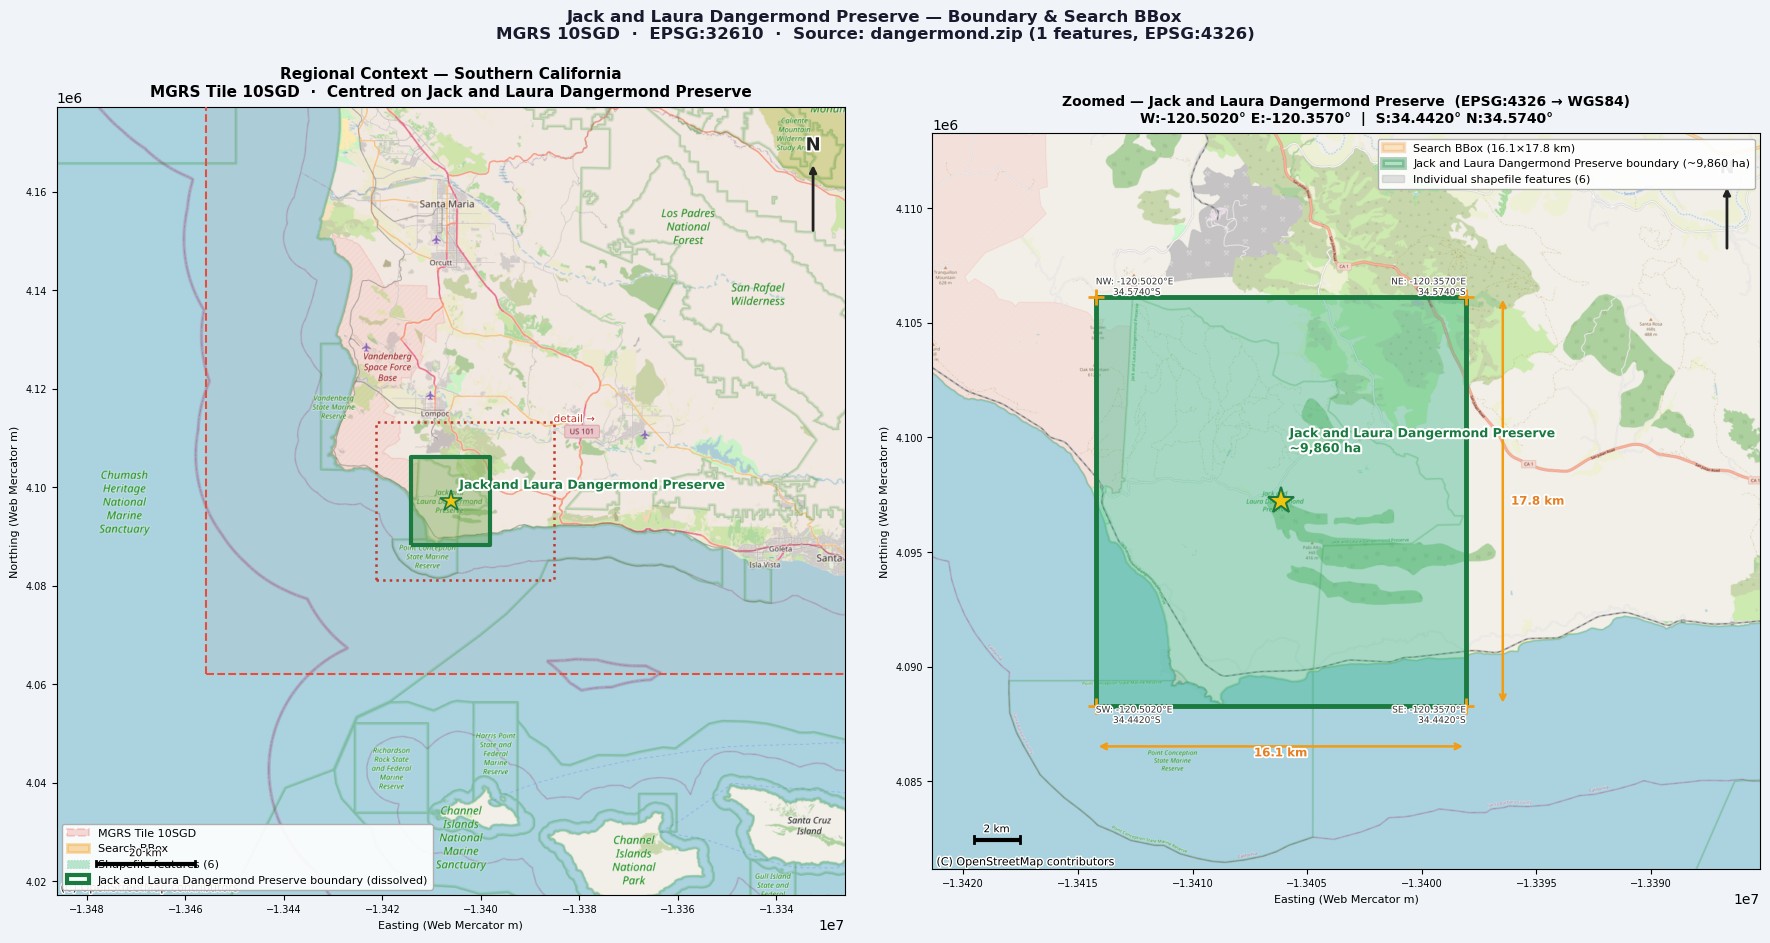

In [4]:
# Cell 3b (Updated): Map using exact Betampona shapefile boundary
# 6-feature shapefile dissolved to single polygon, EPSG:32739 → WGS84

import matplotlib.pyplot      as plt
import matplotlib.patches     as mpatches
import matplotlib.patheffects as pe
import geopandas              as gpd
from pathlib          import Path
from pyproj           import Transformer

# ── Install contextily if needed ──────────────────────────────────────────────
try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,"-m","pip",
                           "install","contextily","-q"])
    try:
        import contextily as ctx
        HAS_CTX = True
    except ImportError:
        HAS_CTX = False

CRS_PLOT = "EPSG:3857"   # Web Mercator

# ── Build GeoDataFrames ───────────────────────────────────────────────────────

try:
    roi_fname = "dangermond.zip" # Replace with correct filename
    roi_feat = len(gdf_raw)
    
    # All 6 individual features (for display)
    gdf_features = gpd.read_file(SHP_PATH).to_crs(CRS_PLOT)
    
    # Dissolved single boundary
    gdf_roi = gpd.GeoDataFrame(
        {"label": [SITE_NAME]},
        geometry = [ROI],
        crs      = "EPSG:4326",
    ).to_crs(CRS_PLOT)
    
    # Search bbox
    gdf_bbox = gpd.GeoDataFrame(
        {"label": ["Search BBox"]},
        geometry = [box(*ROI_BBOX)],
        crs      = "EPSG:4326",
    ).to_crs(CRS_PLOT)
except:
    roi_fname = "MGRS Tile"
    roi_feat = 4
    source_crs = "4326"
    gdf_features = None

# MGRS tile
gdf_tile = gpd.GeoDataFrame(
    {"label": [f"MGRS {MGRS_TILE}"]},
    geometry = [box(*BBOX_WGS84)],
    crs      = "EPSG:4326",
).to_crs(CRS_PLOT)

if gdf_features is None:
    gdf_roi = gdf_tile
    gdf_bbox = gdf_tile

# ── Coordinate transformer ────────────────────────────────────────────────────
tf = Transformer.from_crs("EPSG:4326", CRS_PLOT, always_xy=True)

centroid_mx, centroid_my = tf.transform(*ROI_CENTROID)
# toamasina_mx, toamasina_my = tf.transform(49.4018, -18.1492)

# ── Bounds ────────────────────────────────────────────────────────────────────
tile_bounds = gdf_tile.total_bounds
bbox_bounds = gdf_bbox.total_bounds
roi_bounds  = gdf_roi.total_bounds

bbox_w_m = bbox_bounds[2] - bbox_bounds[0]
bbox_h_m = bbox_bounds[3] - bbox_bounds[1]

# Panel extents
left_cx, left_cy = centroid_mx, centroid_my
left_half        = 80_000   # ±80 km

left_xlim  = (left_cx - left_half, left_cx + left_half)
left_ylim  = (left_cy - left_half, left_cy + left_half)

pad_r      = max(bbox_w_m, bbox_h_m) * 0.40
right_xlim = (bbox_bounds[0]-pad_r,   bbox_bounds[2]+pad_r*1.8)
right_ylim = (bbox_bounds[1]-pad_r,   bbox_bounds[3]+pad_r)

# ─────────────────────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor("#f0f4f8")

# ═════════════════════════════════════════════════════════════════════════════
# LEFT PANEL — Regional context
# ═════════════════════════════════════════════════════════════════════════════
ax1.set_facecolor("#cce5ff")
ax1.set_xlim(*left_xlim)
ax1.set_ylim(*left_ylim)

if HAS_CTX:
    try:
        ctx.add_basemap(ax1, crs=CRS_PLOT, zoom=10,
                        source=ctx.providers.OpenStreetMap.Mapnik,
                        zorder=1)
    except Exception as e:
        print(f"⚠️  Left basemap: {e}")

# MGRS tile
gdf_tile.boundary.plot(ax=ax1, color="#e74c3c",
                        linewidth=1.5, linestyle="--", zorder=3)
gdf_tile.plot(ax=ax1, color="#e74c3c", alpha=0.04, zorder=2)

# Search bbox
gdf_bbox.plot(ax=ax1, color="#f39c12", alpha=0.18, zorder=4)
gdf_bbox.boundary.plot(ax=ax1, color="#f39c12",
                        linewidth=2.0, zorder=5)

if not gdf_features is None:
    # Individual shapefile features (light fill, thin outline)
    gdf_features.plot(ax=ax1, color="#27ae60", alpha=0.25, zorder=6)
    gdf_features.boundary.plot(ax=ax1, color="#27ae60",
                                 linewidth=0.8, linestyle=":", zorder=7)

# Dissolved ROI boundary — bold outline
gdf_roi.boundary.plot(ax=ax1, color="#1a7a40",
                       linewidth=3.0, zorder=8)

# Centroid
ax1.plot(centroid_mx, centroid_my,
         marker="*", color="#f1c40f", markersize=16,
         markeredgecolor="#1a7a40", markeredgewidth=1.2, zorder=10)

# Labels
ax1.annotate(
    f"  {SITE_NAME}",
    xy=(centroid_mx, centroid_my + 2500),
    fontsize=9, fontweight="bold", color="#1a7a40", zorder=11,
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
)
# ax1.plot(toamasina_mx, toamasina_my,
#          marker="o", color="#8e44ad", markersize=8,
#          markeredgecolor="white", markeredgewidth=0.8, zorder=10)
# ax1.annotate(
#     "  Toamasina",
#     xy=(toamasina_mx, toamasina_my),
#     fontsize=8, color="#8e44ad", zorder=11,
#     path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
# )

# Inset box
inset_rect = mpatches.Rectangle(
    (right_xlim[0], right_ylim[0]),
    right_xlim[1]-right_xlim[0],
    right_ylim[1]-right_ylim[0],
    linewidth=1.8, edgecolor="#c0392b",
    facecolor="none", linestyle=":", zorder=9,
)
ax1.add_patch(inset_rect)
ax1.annotate(
    "detail →",
    xy=(right_xlim[1], right_ylim[1]),
    fontsize=7.5, color="#c0392b", zorder=11,
    path_effects=[pe.withStroke(linewidth=2, foreground="white")],
)

# Scale bar 20 km
sb_x0 = left_xlim[0] + (left_xlim[1]-left_xlim[0])*0.05
sb_y0 = left_ylim[0] + (left_ylim[1]-left_ylim[0])*0.04
ax1.plot([sb_x0, sb_x0+20_000], [sb_y0, sb_y0],
         color="black", linewidth=3, zorder=12, solid_capstyle="butt")
for x_ in [sb_x0, sb_x0+20_000]:
    ax1.plot([x_,x_],[sb_y0-500,sb_y0+500],
             color="black", linewidth=2, zorder=12)
ax1.text(sb_x0+10_000, sb_y0+1500, "20 km",
         ha="center", fontsize=7.5, zorder=12,
         path_effects=[pe.withStroke(linewidth=2, foreground="white")])

# North arrow
ax1.annotate("N", fontsize=13, fontweight="bold",
             xy=(0.96,0.94), xycoords="axes fraction",
             ha="center", va="bottom", color="#222222",
             path_effects=[pe.withStroke(linewidth=2.5,
                                         foreground="white")])
ax1.annotate("", xy=(0.96,0.93), xycoords="axes fraction",
             xytext=(0.96,0.84), textcoords="axes fraction",
             arrowprops=dict(arrowstyle="-|>",
                             color="#222222", lw=2.0))

legend1 = [
    mpatches.Patch(fc="#e74c3c", alpha=0.2, ec="#e74c3c",
                   ls="--", lw=1.5, label=f"MGRS Tile {MGRS_TILE}"),
    mpatches.Patch(fc="#f39c12", alpha=0.35, ec="#f39c12",
                   lw=2.0, label="Search BBox"),
    mpatches.Patch(fc="#27ae60", alpha=0.30, ec="#27ae60",
                   ls=":", lw=0.8, label="Shapefile features (6)"),
    mpatches.Patch(fc="none", ec="#1a7a40",
                   lw=3.0, label=f"{SITE_NAME} boundary (dissolved)"),
]
ax1.legend(handles=legend1, loc="lower left",
           fontsize=8, framealpha=0.92, edgecolor="#aaaaaa")

ax1.set_title(
    f"Regional Context — Southern California\n" # Replace with correct regional context
    f"MGRS Tile {MGRS_TILE}  ·  Centred on {SITE_NAME}",
    fontsize=11, fontweight="bold", pad=8,
)
ax1.set_xlabel("Easting (Web Mercator m)", fontsize=8)
ax1.set_ylabel("Northing (Web Mercator m)", fontsize=8)
ax1.tick_params(labelsize=7)

# ═════════════════════════════════════════════════════════════════════════════
# RIGHT PANEL — Zoomed ROI
# ═════════════════════════════════════════════════════════════════════════════
ax2.set_facecolor("#cce5ff")
ax2.set_xlim(*right_xlim)
ax2.set_ylim(*right_ylim)

if HAS_CTX:
    try:
        ctx.add_basemap(ax2, crs=CRS_PLOT, zoom=13,
                        source=ctx.providers.OpenStreetMap.Mapnik,
                        zorder=1)
    except Exception as e:
        print(f"⚠️  Right basemap: {e}")

# Search bbox
gdf_bbox.plot(ax=ax2, color="#f39c12", alpha=0.08, zorder=3)
gdf_bbox.boundary.plot(ax=ax2, color="#f39c12",
                        linewidth=2.5, zorder=4)

if not gdf_features is None:
    # Individual features — coloured by feature index
    colors = ["#1abc9c","#3498db","#9b59b6",
              "#e67e22","#e74c3c","#2ecc71"]
    for i, (_, row) in enumerate(gdf_features.iterrows()):
        feat_gdf = gpd.GeoDataFrame(
            geometry=[row.geometry], crs=CRS_PLOT
        )
        feat_gdf.plot(ax=ax2,
                      color=colors[i % len(colors)],
                      alpha=0.35, zorder=5)
        feat_gdf.boundary.plot(ax=ax2,
                                color=colors[i % len(colors)],
                                linewidth=1.0, zorder=6)

# Dissolved boundary — bold
gdf_roi.boundary.plot(ax=ax2, color="#1a7a40",
                       linewidth=3.5, zorder=7)

# Centroid star
ax2.plot(centroid_mx, centroid_my,
         marker="*", color="#f1c40f", markersize=20,
         markeredgecolor="#1a7a40", markeredgewidth=1.5, zorder=9)

# Site label
ax2.annotate(
    f"  {SITE_NAME}\n  ~{SITE_AREA_HA:,} ha",
    xy=(centroid_mx, centroid_my + bbox_h_m*0.12),
    fontsize=9, fontweight="bold", color="#1a7a40", zorder=10,
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
)

# Corner coordinate labels
corners = [
    (ROI_BBOX[0], ROI_BBOX[3], "NW", "left",  "bottom"),
    (ROI_BBOX[2], ROI_BBOX[3], "NE", "right", "bottom"),
    (ROI_BBOX[0], ROI_BBOX[1], "SW", "left",  "top"   ),
    (ROI_BBOX[2], ROI_BBOX[1], "SE", "right", "top"   ),
]
for lon, lat, lbl, ha, va in corners:
    mx, my = tf.transform(lon, lat)
    ax2.plot(mx, my, marker="+", color="#f39c12",
             markersize=12, markeredgewidth=2.0, zorder=8)
    ax2.annotate(
        f"{lbl}: {lon:.4f}°E\n      {abs(lat):.4f}°S",
        xy=(mx, my), fontsize=6.5, ha=ha, va=va,
        color="#333333", zorder=10,
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )

# Dimension arrows
roi_w_km = bbox_w_m / 1000
roi_h_km = bbox_h_m / 1000

y_arr = bbox_bounds[1] - bbox_h_m*0.10
ax2.annotate("",
    xy=(bbox_bounds[2], y_arr),
    xytext=(bbox_bounds[0], y_arr),
    arrowprops=dict(arrowstyle="<->", color="#f39c12", lw=1.8),
    zorder=7)
ax2.text((bbox_bounds[0]+bbox_bounds[2])/2, y_arr,
         f"  {roi_w_km:.1f} km  ",
         ha="center", va="top", fontsize=8.5,
         color="#e67e22", fontweight="bold",
         path_effects=[pe.withStroke(linewidth=2.5,
                                     foreground="white")],
         zorder=8)

x_arr = bbox_bounds[2] + bbox_w_m*0.10
ax2.annotate("",
    xy=(x_arr, bbox_bounds[3]),
    xytext=(x_arr, bbox_bounds[1]),
    arrowprops=dict(arrowstyle="<->", color="#f39c12", lw=1.8),
    zorder=7)
ax2.text(x_arr, (bbox_bounds[1]+bbox_bounds[3])/2,
         f"  {roi_h_km:.1f} km",
         ha="left", va="center", fontsize=8.5,
         color="#e67e22", fontweight="bold",
         path_effects=[pe.withStroke(linewidth=2.5,
                                     foreground="white")],
         zorder=8)

# Scale bar 2 km
sb2_x0 = right_xlim[0] + (right_xlim[1]-right_xlim[0])*0.05
sb2_y0 = right_ylim[0] + (right_ylim[1]-right_ylim[0])*0.04
ax2.plot([sb2_x0, sb2_x0+2_000], [sb2_y0, sb2_y0],
         color="black", linewidth=3, zorder=12,
         solid_capstyle="butt")
for x_ in [sb2_x0, sb2_x0+2_000]:
    ax2.plot([x_,x_],
             [sb2_y0-bbox_h_m*0.008, sb2_y0+bbox_h_m*0.008],
             color="black", linewidth=2, zorder=12)
ax2.text(sb2_x0+1_000, sb2_y0+bbox_h_m*0.018,
         "2 km", ha="center", fontsize=7.5, zorder=12,
         path_effects=[pe.withStroke(linewidth=2, foreground="white")])

# North arrow
ax2.annotate("N", fontsize=13, fontweight="bold",
             xy=(0.96,0.94), xycoords="axes fraction",
             ha="center", va="bottom", color="#222222",
             path_effects=[pe.withStroke(linewidth=2.5,
                                         foreground="white")])
ax2.annotate("", xy=(0.96,0.93), xycoords="axes fraction",
             xytext=(0.96,0.84), textcoords="axes fraction",
             arrowprops=dict(arrowstyle="-|>",
                             color="#222222", lw=2.0))

legend2 = [
    mpatches.Patch(fc="#f39c12", alpha=0.25, ec="#e67e22",
                   lw=2.5,
                   label=f"Search BBox ({roi_w_km:.1f}×{roi_h_km:.1f} km)"),
    mpatches.Patch(fc="#27ae60", alpha=0.35, ec="#1a7a40",
                   lw=3.5,
                   label=f"{SITE_NAME} boundary (~{SITE_AREA_HA:,} ha)"),
    mpatches.Patch(fc="#aaaaaa", alpha=0.35, ec="#aaaaaa",
                   lw=1.0, label="Individual shapefile features (6)"),
]
ax2.legend(handles=legend2, loc="upper right",
           fontsize=8, framealpha=0.92, edgecolor="#aaaaaa")

ax2.set_title(
    f"Zoomed — {SITE_NAME}  (EPSG:{source_crs} → WGS84)\n"
    f"W:{ROI_BBOX[0]:.4f}° E:{ROI_BBOX[2]:.4f}°  |  "
    f"S:{ROI_BBOX[1]:.4f}° N:{ROI_BBOX[3]:.4f}°",
    fontsize=10, fontweight="bold", pad=8,
)
ax2.set_xlabel("Easting (Web Mercator m)", fontsize=8)
ax2.set_ylabel("Northing (Web Mercator m)", fontsize=8)
ax2.tick_params(labelsize=7)

# ── Overall title ─────────────────────────────────────────────────────────────
fig.suptitle(
    f"{SITE_NAME} — Boundary & Search BBox\n"
    f"MGRS {MGRS_TILE}  ·  EPSG:{TARGET_EPSG}  ·  "
    f"Source: {roi_fname} ({roi_feat} features, EPSG:{source_crs})",
    fontsize=12, fontweight="bold", y=1.01, color="#1a1a2e",
)

plt.tight_layout()

# map_path = Path(FIG_DIR) / f"{SITE_NAME}_boundary_map_{MGRS_TILE}.png"
# Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
# plt.savefig(map_path, dpi=200, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
plt.show()
# print(f"\n✅ Map saved → {map_path}")

## Grabbing the HDF files

In [4]:
import earthaccess
from pathlib import Path
from tqdm    import tqdm

# Suppress warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

HDF4_MAGIC = b"\x0e\x03\x13\x01"

def is_valid_hdf(fpath: Path) -> bool:
    if not fpath.exists() or fpath.stat().st_size < 100_000:
        return False
    with open(fpath, "rb") as fh:
        return fh.read(4) == HDF4_MAGIC

downloaded_files = {}

for short_name, version in PRODUCTS_TO_FETCH:

    print(f"\n{'─'*55}")
    print(f"🔎 {short_name} v{version}")
    print(f"{'─'*55}")

    results = earthaccess.search_data(
        short_name   = short_name,
        version      = version,
        bounding_box = SEARCH_BBOX,
        temporal     = (START_DATE, END_DATE),
        count        = -1,
    )
    print(f"   CMR results  : {len(results)} granules")

    if not results:
        print(f"   ⚠️  No granules found.")
        downloaded_files[short_name] = []
        continue

    # Filter to granules with HDF links
    hdf_granules = []
    for granule in results:
        try:
            links = (granule.data_links(access="external") +
                     granule.data_links(access="on_prem"))
        except Exception:
            links = [u["URL"] for u in
                     granule.get("umm",{}).get("RelatedUrls",[])
                     if "URL" in u]
        if any(Path(lnk).suffix.lower() == ".hdf" for lnk in links):
            hdf_granules.append(granule)

    print(f"   HDF granules : {len(hdf_granules)}")

    product_dir = Path(DIR_HDF) / short_name
    product_dir.mkdir(parents=True, exist_ok=True)

    raw_files = earthaccess.download(
        hdf_granules, local_path=str(product_dir)
    )

    # Verify — remove non-HDF files
    valid_hdfs, removed = [], 0
    for f in raw_files:
        fpath = Path(f)
        if is_valid_hdf(fpath):
            valid_hdfs.append(fpath)
        else:
            fpath.unlink(missing_ok=True)
            removed += 1

    downloaded_files[short_name] = valid_hdfs
    print(f"   Valid HDF    : {len(valid_hdfs)}")
    if removed:
        print(f"   Removed      : {removed} non-HDF files")
    print(f"   Saved to     : {product_dir}")

print(f"\n✅ Download complete.")


───────────────────────────────────────────────────────
🔎 MOD13Q1 v061
───────────────────────────────────────────────────────
   CMR results  : 232 granules
   HDF granules : 232


QUEUEING TASKS | :   0%|          | 0/679 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/679 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/679 [00:00<?, ?it/s]

   Valid HDF    : 232
   Removed      : 447 non-HDF files
   Saved to     : modis_veg_indices/10SGD/modis_hdf/MOD13Q1

✅ Download complete.


## 3. Clean data and convert HDF to TIFF
This section parses the HDF files to actually get the desired bands (NDVI, EVI, QA, DOY, RED, NIR, BLUE). It also cleans the data to ensure there are no fill values or values outside the valid range, as well as doing some QA masking to remove clouds, snow, ice, and water. The QA masking also removes data that is not good quality or useful. There shouldn't be anything that needs to be changed in this section, unless the masking seems too strict or not strict enough, in which case just change the mask_qa_values() function. Note that if you want to replace files after making any changes to the processing you will have to comment out the lines that check if the file already exists and just grabs it.

In [5]:
import rioxarray
import rasterio
import numpy    as np
import pandas   as pd
import subprocess, re, warnings
from pathlib          import Path
from tqdm             import tqdm
from rasterio.enums   import Resampling as RasterioResampling
from rasterio.shutil  import copy as rio_copy

try:
    from rioxarray.enums import Resampling
except ImportError:
    from rasterio.enums  import Resampling

# ── Layer configuration — includes DOY for all composite products ─────────────
# https://lpdaac.usgs.gov/documents/621/MOD13_User_Guide_V61.pdf
LAYER_CONFIG = {
    "MOD13Q1": {
        "layers": {
            "QA"  : "250m 16 days VI Quality",
            "NDVI": "250m 16 days NDVI",
            "EVI" : "250m 16 days EVI",
            "RED" : "250m 16 days red reflectance",
            "NIR" : "250m 16 days NIR reflectance",
            "DOY" : "250m 16 days composite day of the year",
        },
        "scale"  : {"NDVI": 0.0001, "EVI": 0.0001, "RED": 0.0001, "NIR": 0.0001},
        "valid"  : {
            "QA"  : (0, 65534),
            "NDVI": (-2000, 10000),
            "EVI" : (-2000, 10000),
            "RED" : (0, 10000),
            "NIR" : (0, 10000),
            "DOY" : (1, 366),
        },
        "nodata" : {
            "QA"  : -3000,
            "NDVI": -3000,
            "EVI" : -3000,
            "RED" : -1000,
            "NIR" : -1000,
            "DOY" : 65535,
        },
        "dtype"  : {
            "QA"  : "uint16",
            "NDVI": "float32",
            "EVI" : "float32",
            "RED" : "float32",
            "NIR" : "float32",
            "DOY" : "int16",
        },
    },
    "MYD13Q1": {
        "layers": {
            "QA"  : "250m 16 days VI Quality",
            "NDVI": "250m 16 days NDVI",
            "EVI" : "250m 16 days EVI",
            "DOY" : "250m 16 days composite day of the year",
        },
        "scale"  : {"NDVI": 0.0001, "EVI": 0.0001},
        "valid"  : {
            "NDVI": (-2000, 10000),
            "EVI" : (-2000, 10000),
            "DOY" : (1, 366),
        },
        "nodata" : -3000,
        "dtype"  : {
            "QA"  : "uint16",
            "NDVI": "float32",
            "EVI" : "float32",
            "DOY" : "int16",
        },
    },
    "MOD13A2": {
        "layers": {
            "QA"  : "1 km 16 days VI Quality",
            "NDVI": "1 km 16 days NDVI",
            "EVI" : "1 km 16 days EVI",
            "DOY" : "1 km 16 days composite day of the year",
        },
        "scale"  : {"NDVI": 0.0001, "EVI": 0.0001},
        "valid"  : {
            "NDVI": (-2000, 10000),
            "EVI" : (-2000, 10000),
            "DOY" : (1, 366),
        },
        "nodata" : -3000,
        "dtype"  : {
            "QA"  : "uint16",
            "NDVI": "float32",
            "EVI" : "float32",
            "DOY" : "int16",
        },
    },
    "MYD13A2": {
        "layers": {
            "QA"  : "1 km 16 days VI Quality",
            "NDVI": "1 km 16 days NDVI",
            "EVI" : "1 km 16 days EVI",
            "DOY" : "1 km 16 days composite day of the year",
        },
        "scale"  : {"NDVI": 0.0001, "EVI": 0.0001},
        "valid"  : {
            "NDVI": (-2000, 10000),
            "EVI" : (-2000, 10000),
            "DOY" : (1, 366),
        },
        "nodata" : -3000,
        "dtype"  : {
            "QA"  : "uint16",
            "NDVI": "float32",
            "EVI" : "float32",
            "DOY" : "int16",
        },
    },
    "MOD09GA": {
        "layers": {
            "Red" : "sur_refl_b01_1",
            "NIR" : "sur_refl_b02_1",
            "Blue": "sur_refl_b03_1",
        },
        "scale"  : {"Red": 0.0001, "NIR": 0.0001, "Blue": 0.0001},
        "valid"  : {
            "Red" : (-100, 16000),
            "NIR" : (-100, 16000),
            "Blue": (-100, 16000),
        },
        "nodata" : -28672,
        "dtype"  : {
            "Red" : "float32",
            "NIR" : "float32",
            "Blue": "float32",
        },
    },
    "MYD09GA": {
        "layers": {
            "Red" : "sur_refl_b01_1",
            "NIR" : "sur_refl_b02_1",
            "Blue": "sur_refl_b03_1",
        },
        "scale"  : {"Red": 0.0001, "NIR": 0.0001, "Blue": 0.0001},
        "valid"  : {
            "Red" : (-100, 16000),
            "NIR" : (-100, 16000),
            "Blue": (-100, 16000),
        },
        "nodata" : -28672,
        "dtype"  : {
            "Red" : "float32",
            "NIR" : "float32",
            "Blue": "float32",
        },
    },
}

# ─────────────────────────────────────────────────────────────────────────────
# Helper functions
# ─────────────────────────────────────────────────────────────────────────────

def get_sds_path(hdf_path: Path, layer_substr: str) -> str:
    result = subprocess.run(
        ["gdalinfo", str(hdf_path)], capture_output=True, text=True
    )
    for line in result.stdout.splitlines():
        if "SUBDATASET" in line and "_NAME=" in line and layer_substr in line:
            return line.split("=",1)[1].strip()
    available = [
        line.split("=",1)[1].strip()
        for line in result.stdout.splitlines()
        if "SUBDATASET" in line and "_NAME=" in line
    ]
    raise ValueError(
        f"Layer '{layer_substr}' not found in {hdf_path.name}.\n"
        f"Available:\n" + "\n".join(f"  {s}" for s in available)
    )

def parse_modis_date(fname: str) -> pd.Timestamp:
    m = re.search(r'\.A(\d{4})(\d{3})\.', fname)
    if not m:
        m = re.search(r'A(\d{4})(\d{3})', fname)
    if not m:
        raise ValueError(f"Cannot parse date from: {fname}")
    return (pd.Timestamp(f"{m.group(1)}-01-01")
            + pd.Timedelta(days=int(m.group(2))-1))

def fix_y_axis(da):
    """Ensure y runs N→S (decreasing). Flip if S→N (increasing)."""
    if len(da.y) > 1 and da.y.values[-1] > da.y.values[0]:
        da = da.isel(y=slice(None,None,-1))
    return da

def mask_fill_values(da, nodata_raw, valid_range=None):
    """Mask nodata, out-of-range, and overflow values before cast."""
    da = da.where(da != nodata_raw)
    if valid_range is not None:
        vmin, vmax = valid_range
        da = da.where((da >= vmin) & (da <= vmax))
    da = da.where((da > -1e10) & (da < 1e10))
    return da

def mask_qa_values(da, qa):
    """Mask clouds, snow, ice, and water values before cast."""
    adjacent_cloud = ((qa >> 8) & 1) == 1
    mixed_cloud = ((qa >> 10) & 1) == 1
    snow_ice = ((qa >> 14) & 1) == 1
    land_water = (qa >> 11) & 0b111
    land = land_water == 1
    vi_quality = qa & 0b11
    good = vi_quality == 0
    usefulness = (qa >> 2) & 0b1111
    useful = usefulness <= 2
    mask = (
        good &
        useful &
        land &
        ~adjacent_cloud &
        ~mixed_cloud &
        ~snow_ice
    )
    da = da.where(mask)
    return da

def evi2_calc(red, nir):
    evi2 = 2.5 * (nir - red) / (nir + 2.4 * red + 1) # Jiang et al., 2008 
    lower_bound = evi2 >= -2
    upper_bound = evi2 <= 10
    valid = lower_bound & upper_bound
    return evi2.where(valid)

def safe_cast(arr: np.ndarray, dtype: str) -> np.ndarray:
    """Clip to dtype range and cast — no RuntimeWarning."""
    if dtype == "float32":
        f32_min = float(np.finfo(np.float32).min)
        f32_max = float(np.finfo(np.float32).max)
        arr_out = np.where(
            np.isfinite(arr),
            np.clip(arr, f32_min, f32_max),
            np.nan
        )
        return arr_out.astype(np.float32)
    elif dtype == "uint16":
        arr_out = np.where(np.isnan(arr.astype(float)), 65535.0, arr)
        return np.clip(arr_out, 0, 65534).astype(np.uint16)
    elif dtype == "int16":
        # DOY: valid 1–366, nodata sentinel = -1
        arr_out = np.where(np.isnan(arr.astype(float)), -1.0, arr)
        return np.clip(arr_out, -1, 366).astype(np.int16)
    else:
        return arr.astype(dtype)

def build_tiff_profile(da, dtype: str, nodata_val):
    """Build rasterio profile. Returns (profile, da) — da may be y-flipped."""
    transform = da.rio.transform()
    if transform.e > 0:
        da        = da.isel(y=slice(None,None,-1))
        transform = da.rio.transform()
    predictor = 3 if np.issubdtype(np.dtype(dtype), np.floating) else 2
    profile = {
        "driver"    : "GTiff",
        "dtype"     : dtype,
        "width"     : da.shape[-1],
        "height"    : da.shape[-2],
        "count"     : 1,
        "crs"       : da.rio.crs,
        "transform" : transform,
        "nodata"    : nodata_val,
        "compress"  : "deflate",
        "predictor" : predictor,
        "zlevel"    : 6,
        "tiled"     : True,
        "blockxsize": 512,
        "blockysize": 512,
    }
    return profile, da

def write_geotiff(da, out_path: Path, dtype: str,
                  nodata_val, tags: dict, tiff_format: str):
    """
    Write DataArray to COG or standard GeoTIFF.
    copy_src_overviews passed ONLY to rio_copy — never in profile dict.
    """
    profile, da = build_tiff_profile(da, dtype, nodata_val)
    arr         = safe_cast(da.values, dtype)

    if tiff_format == "COG":
        tmp_path = out_path.with_suffix(".tmp.tif")
        with rasterio.open(tmp_path, "w", **profile) as dst:
            dst.write(arr, 1)
            dst.update_tags(**tags)
        with rasterio.open(tmp_path, "r+") as tmp:
            tmp.build_overviews([2,4,8,16,32], RasterioResampling.average)
            tmp.update_tags(ns="rio_overview", resampling="average")
        rio_copy(tmp_path, out_path,
                 copy_src_overviews=True, **profile)   # ← only here
        tmp_path.unlink(missing_ok=True)
    else:
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(arr, 1)
            dst.update_tags(**tags)

def hdf_to_geotiff(hdf_path: Path, short_name: str,
                   target_epsg: int, out_dir: Path,
                   tiff_format: str = "COG") -> dict:
    """
    Convert one MODIS HDF4 → one GeoTIFF per band.
    Returns {band_name: Path}. Skips existing files.
    File naming: {short_name}_{band}_{YYYYMMDD}.tif
    """
    config    = LAYER_CONFIG[short_name]
    date      = parse_modis_date(hdf_path.name)
    date_tag  = date.strftime("%Y%m%d")
    out_paths = {}

    # Store QA to mask, store Red and NIR to calculate EVI2
    qa = red = nir = evi2 = None
    
    for band_name, layer_key in config["layers"].items():

        out_tif = out_dir / f"{short_name}_{band_name}_{date_tag}.tif"

        if out_tif.exists():
            out_paths[band_name] = out_tif
            
            # Check pixel count in search bbox
            # from rasterio.windows import from_bounds
            
            # with rasterio.open(out_tif) as src:
            #     window = from_bounds(
            #         SEARCH_BBOX[0], SEARCH_BBOX[1], SEARCH_BBOX[2], SEARCH_BBOX[3],
            #         transform=src.transform
            #     )
            #     pixel_count = window.width * window.height
            #     print(pixel_count)
     
            continue

        try:
            sds = get_sds_path(hdf_path, layer_key)
            da  = rioxarray.open_rasterio(
                      sds, masked=True, lock=False
                  ).squeeze("band", drop=True)
            da = da.rio.write_crs(SINU_CRS)
            da = fix_y_axis(da)
           
            # Grab qa mask
            if band_name == 'QA':
                qa = da.copy()
                # Should be uint16
                qa = qa.astype(config['dtype']['QA'])
            
            da = mask_fill_values(
                da,
                nodata_raw  = config["nodata"],
                valid_range = config["valid"].get(band_name),
            )
            
            # Apply qa mask if relevant
            if not qa is None and (band_name == 'NDVI' or band_name == 'EVI'
                                   or band_name == 'RED' or bane_name == 'NIR'):
                da = mask_qa_values(da, qa)
                
            da = da.rio.reproject(
                f"EPSG:{target_epsg}",
                resampling = Resampling.bilinear,
                nodata     = np.nan,
            )
            da = fix_y_axis(da)

            if band_name in config["scale"]:
                da = da * config["scale"][band_name]

            dtype = config["dtype"].get(band_name, "float32")
            if dtype == "uint16":
                nodata_v = np.uint16(65535)
            elif dtype == "int16":
                nodata_v = np.int16(-1)
            else:
                nodata_v = np.float32(np.nan)

            tags = {
                "MODIS_product"   : short_name,
                "band"            : band_name,
                "acquisition_date": date_tag,
                "source_hdf"      : hdf_path.name,
                "crs"             : f"EPSG:{target_epsg}",
                "utm_zone"        : f"{MGRS_ZONE}{HEMI}",
                "mgrs_tile"       : MGRS_TILE,
                "scale_applied"   : str(config["scale"].get(band_name,"none")),
            }

            # Grab Red
            if band_name == 'RED':
                red = da.copy()

            # Grab NIR
            if band_name == 'NIR':
                nir = da.copy()

            # Calculate and write EVI2 to tif once Red and NIR available
            if not red is None and not nir is None and evi2 is None:
                evi2 = evi2_calc(red, nir)
                out_tif = out_dir / f"{short_name}_EVI2_{date_tag}.tif"
                tags = {
                    "MODIS_product"   : short_name,
                    "band"            : "EVI2",
                    "acquisition_date": date_tag,
                    "source_hdf"      : "N/A",
                    "crs"             : f"EPSG:{target_epsg}",
                    "utm_zone"        : f"{MGRS_ZONE}{HEMI}",
                    "mgrs_tile"       : MGRS_TILE,
                    "scale_applied"   : str(config["scale"].get(band_name,"none")),
                }
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", RuntimeWarning)
                    write_geotiff(evi2, out_tif, dtype, nodata_v,
                                  tags, tiff_format)
                out_paths["EVI2"] = out_tif
            
            # Don't write Red and NIR to tif
            if band_name != 'RED' and band_name != 'NIR':
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", RuntimeWarning)
                    write_geotiff(da, out_tif, dtype, nodata_v,
                                  tags, tiff_format)
                out_paths[band_name] = out_tif

        except Exception as e:
            print(f"\n     ⚠️  {band_name} [{hdf_path.name}]: "
                  f"{type(e).__name__}: {e}")

    return out_paths

# ── Conversion loop ───────────────────────────────────────────────────────────
converted_files = {}

for short_name, hdf_files in downloaded_files.items():

    if short_name not in LAYER_CONFIG:
        print(f"⚠️  No layer config for '{short_name}' — skipping.")
        continue

    out_dir = Path(DIR_TIFF) / short_name
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'─'*55}")
    print(f"🔄 {short_name}: {len(hdf_files)} HDF → {TIFF_FORMAT} GeoTIFF")
    print(f"   Output : {out_dir}")
    print(f"{'─'*55}")

    band_paths = {b: [] for b in LAYER_CONFIG[short_name]["layers"]}
    failed     = []

    for hdf_file in tqdm(sorted(hdf_files), desc=f"  {short_name}"):
        try:
            result = hdf_to_geotiff(
                hdf_path    = Path(hdf_file),
                short_name  = short_name,
                target_epsg = TARGET_EPSG,
                out_dir     = out_dir,
                tiff_format = TIFF_FORMAT,
            )
            for band_name, tif_path in result.items():
                band_paths[band_name].append(tif_path)
        except Exception as e:
            failed.append(Path(hdf_file).name)
            print(f"\n   ❌ {Path(hdf_file).name}: {e}")

    converted_files[short_name] = band_paths

    print()
    for band_name, paths in band_paths.items():
        print(f"   ✅ {band_name:6s}: {len(paths)} GeoTIFFs")
    if failed:
        print(f"   ❌ Failed : {len(failed)}")
        for f in failed[:5]:
            print(f"      • {f}")

    # Verify first output
    sample_band = next(iter(band_paths))
    if band_paths[sample_band]:
        sample = band_paths[sample_band][0]
        with rasterio.open(sample) as src:
            t = src.transform
            print(f"\n   📋 Verification — {sample.name}")
            print(f"      CRS     : {src.crs}")
            print(f"      Shape   : {src.height} × {src.width}")
            print(f"      Dtype   : {src.dtypes[0]}")
            print(f"      Nodata  : {src.nodata}")
            print(f"      X pixel : {t.a:.2f} m "
                  f"{'✅' if t.a > 0 else '❌ x flipped'}")
            print(f"      Y pixel : {t.e:.2f} m "
                  f"{'✅' if t.e < 0 else '❌ y flipped'}")
            print(f"      Bounds  : {src.bounds}")
            print(f"      Size    : {sample.stat().st_size/1e6:.2f} MB")

print("\n✅ TIFF download complete.")


───────────────────────────────────────────────────────
🔄 MOD13Q1: 232 HDF → COG GeoTIFF
   Output : modis_veg_indices/10SGD/modis_tiff/MOD13Q1
───────────────────────────────────────────────────────


  MOD13Q1:   0%|          | 0/232 [00:00<?, ?it/s]

1.2230569858275756e-07
1.2230569858275756e-07
1.2230569858275756e-07


  MOD13Q1:   0%|          | 1/232 [00:15<57:48, 15.01s/it]

1.2230569858275756e-07
1.2230569858275756e-07
1.2230569858275756e-07
1.2230569858275756e-07


...

1.2230569858275756e-07
1.2230569858275756e-07
1.2230569858275756e-07
1.2230569858275756e-07


  MOD13Q1: 100%|█████████▉| 231/232 [55:05<00:14, 14.70s/it]

1.2230569858275756e-07
1.2230569858275756e-07
1.2230569858275756e-07
1.2230569858275756e-07


  MOD13Q1: 100%|██████████| 232/232 [55:18<00:00, 14.30s/it]

1.2230569858275756e-07

   ✅ QA    : 232 GeoTIFFs
   ✅ NDVI  : 232 GeoTIFFs
   ✅ EVI   : 232 GeoTIFFs
   ✅ RED   : 232 GeoTIFFs
   ✅ NIR   : 232 GeoTIFFs
   ✅ DOY   : 232 GeoTIFFs

   📋 Verification — MOD13Q1_QA_20151219.tif
      CRS     : EPSG:32610
      Shape   : 2812 × 6322
      Dtype   : uint16
      Nodata  : 65535.0
      X pixel : 395.59 m ✅
      Y pixel : -395.59 m ✅
      Bounds  : BoundingBox(left=-143997.279208016, bottom=3342678.9263950717, right=2356936.036759438, top=4455083.938179393)
      Size    : 5.25 MB

✅ TIFF download complete.


In [ ]:
# Load MERRA2 -- chose this file because the spatial plotting earlier revealed it to be the one that HLS tile 39LUD sits in
# TODO: **** edit later ****
arr = np.load('/shared/users/sapolinsky/MERRA2_files/ignore_for_now/DPTarr_MERRA2_E0493_S0180.npy')
# arr = np.load('/shared/users/sapolinsky/MERRA2_files/DPTarr_MERRA2_E0500_S0154.npy')

# create a pandas dataframe of the date, precipitation, and temperature from the MERRA2 numpy file
merra2_df = pd.DataFrame({
    'date': pd.to_datetime(dates.num2date(arr[:, 0]), errors='coerce'),
    'precip': arr[:, 1],
    'temp': arr[:, 2]
}).set_index('date')

merra2_df.index = merra2_df.index.tz_localize(None)  # remove timezone to match HLS dates

# Aggregate MERRA2 to 10-day means/sums to match HLS cadence
hls_dates = pd.read_csv(clipped_roi_ndvi_file.with_suffix('').as_posix() + "_dates.csv", header=None, parse_dates=[0]).squeeze()
hls_dates = pd.to_datetime(hls_dates).sort_values().reset_index(drop=True)

records = []
for i, start in enumerate(hls_dates):
    # end is the day before the next start date (or +10 days for the last)
    end = hls_dates.iloc[i+1] if i+1 < len(hls_dates) else start + pd.Timedelta(days=10)
    window = merra2_df[(merra2_df.index >= start) & (merra2_df.index < end)]
    records.append({
        'date': start,
        'precip': window['precip'].mean(),
        'temp': window['temp'].mean()
    })

merra2_10day = pd.DataFrame(records).set_index('date')

# Aggregate HLS spatially (mean over all pixels per time step)
ndvi_ts = tenday_ndvis.mean(dim=['x', 'y'])
ndvi_df = ndvi_ts.to_dataframe(name='ndvi').reset_index().set_index('time')

evi_ts = tenday_evis.mean(dim=['x', 'y'])
evi_df = evi_ts.to_dataframe(name='evi').reset_index().set_index('time')

evi2_ts = tenday_evi2s.mean(dim=['x', 'y'])
evi2_df = evi2_ts.to_dataframe(name='evi2').reset_index().set_index('time')

# Merge on date
merged = merra2_10day.join(ndvi_df['ndvi'], how='inner')
merged = merged.join(evi_df['evi'], how='inner')
merged = merged.join(evi2_df['evi2'], how='inner')

#### Plot precipitation, temperature, NDVI, EVI, EVI2 data
These plots provide an overview of the data and to see how the vegetation indices change as climate changes.

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 8), sharex=True)

axes[0].plot(merged.index, merged['precip'], color='blue')
axes[0].set_ylabel('Precip [cm]')

axes[1].plot(merged.index, merged['temp'], color='red')
axes[1].set_ylabel('Temp [°C]')

axes[2].plot(merged.index, merged['ndvi'], color='green')
axes[2].set_ylabel('NDVI')

axes[3].plot(merged.index, merged['evi'], color='orange')
axes[3].set_ylabel('EVI')

axes[4].plot(merged.index, merged['evi2'], color='purple')
axes[4].set_ylabel('EVI2')

for ax in axes:
    ax.grid(True, color='lightgrey', linewidth=0.5)
    ax.set_facecolor('white')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

#### Vegetation Index vs. Precip/Temp
We want to see how/if EVI, NDVI, and EVI2 change with changing teperature and precipitation by plotting EVI, EVI2, and NDVI on the y-axis and the climate variables on the x-axes. 

In [ ]:
# Chart of how NDVI, EVI, and EVI2 change with changing precipitation and temperature
merged_clean = merged.dropna()
fig, ax = plt.subplots(2, 1)
ax[0].scatter(merged_clean['precip'], merged_clean['ndvi'], alpha=0.5)
ax[0].scatter(merged_clean['precip'], merged_clean['evi'], alpha=0.5)
ax[0].scatter(merged_clean['precip'], merged_clean['evi2'], alpha=0.5)
ax[0].set_ylabel('NDVI, EVI, EVI2')
ax[0].set_xlabel('Precipitation (cm)')
ax[0].legend(['NDVI', 'EVI', 'EVI2'], loc='lower right')

ax[1].scatter(merged_clean['temp'], merged_clean['ndvi'], alpha=0.5)
ax[1].scatter(merged_clean['temp'], merged_clean['evi'], alpha=0.5)
ax[1].scatter(merged_clean['temp'], merged_clean['evi2'], alpha=0.5)
ax[1].set_ylabel('NDVI, EVI, EVI2')
ax[1].set_xlabel('Temperature (C)')
ax[1].legend(['NDVI', 'EVI', 'EVI2'], loc='lower right')

plt.tight_layout()
plt.show()

As these plots show, for this site, there is very little (or no) correlation between vegetation indices and precipitation/temperature. This could be due to this site being vegetated year-round, or there being relatively little variation in temperature throughout the year (min = about 16˚C or 60˚F, max = about 25˚C or 77˚F). 

#### Monthly averages

In [ ]:
# monthly climate from daily MERRA2
climate_monthly = merra2_df.resample('ME').agg(
    {'precip': 'sum', 'temp': ['mean', 'min', 'max']})
climate_monthly.columns = ['precip_sum', 'temp_mean', 'temp_min', 'temp_max']

# monthly vegetation from 10-day HLS
veg_monthly = pd.DataFrame({
    'ndvi': ndvi_df['ndvi'].resample('ME').mean(),
    'evi':  evi_df['evi'].resample('ME').mean(),
    'evi2': evi2_df['evi2'].resample('ME').mean()
})

# merge at monthly level
monthly_all = climate_monthly.join(veg_monthly, how='inner')
monthly_all = monthly_all['2016':'2025']
monthly_all

#### Cloud cover
Cloud cover here is defined as the percentage of NaN (not a number) pixels in a composite. This may not be entirely representative of actual cloud data given that clouds, shadows, and other non-vegetated pixels were all masked out in the creation of the 10-day HLS composites. 

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# average across all pixels at each timestep, ignoring NaNs
ndvi_mean = tenday_ndvis.mean(dim=["x", "y"], skipna=True)
evi_mean = tenday_evis.mean(dim=["x", "y"], skipna=True)
evi2_mean = tenday_evi2s.mean(dim=["x", "y"], skipna=True)

# count NaN pixels at each timestep, express as % of total pixels
total_pixels = tenday_ndvis.sizes["x"] * tenday_ndvis.sizes["y"]
nan_count = tenday_ndvis.isnull().sum(dim=["x", "y"])
cloud_pct = (nan_count / total_pixels) * 100

# time axis
time = tenday_ndvis.time.values
time_evi = tenday_evis.time.values

# vegetation indices
# cloud cover as background shading 
# high cloud = tall shading from the top
axes[0].fill_between(time, cloud_pct/100, alpha=0.15, label="Cloud cover % (NaN pixels)", zorder=1)
axes[0].plot(time, ndvi_mean, label='NDVI')
axes[0].plot(time_evi, evi_mean, label='EVI')
axes[0].plot(time, evi2_mean, label='EVI2')
axes[0].set_ylabel('Vegetation Index')
axes[0].legend(loc='lower left')

# precipitation
axes[1].bar(monthly_all.index, monthly_all['precip_sum'], width=20)
axes[1].set_ylabel('Monthly Precip [cm]')

# temperature
axes[2].plot(monthly_all.index, monthly_all['temp_mean'], color='black', label='mean')
axes[2].plot(monthly_all.index, monthly_all['temp_min'], color='blue', label='min')
axes[2].plot(monthly_all.index, monthly_all['temp_max'], color='red', label='max')
axes[2].set_ylabel('Temp [°C]')
axes[2].legend()

for ax in axes:
    ax.grid(True, color='lightgrey', linewidth=0.5)
    ax.set_facecolor('white')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

The plot above represents another way of exploring the data we have. By taking monthly aggregations of precipitation (total) and temperature (mean, min, max), and comparing that with how EVI, EVI2, and NDVI vary and how much cloud cover (NaN pixels) there is, these can reveal additional correlations between data.

#### Z-score plot
To get a better view of how temperature, precipitation, and NDVI/EVI/EVI2 vary from their average over time, here we calculate and plot the z-score of each.

**Z-score**: measures how many standard deviations a specific data point is above or below the mean

In [ ]:
# drop rows where any column is NaN for clean correlation
monthly_clean = monthly_all.dropna()

# Z-scores
ndvi_z = stats.zscore(monthly_clean['ndvi'])
precip_z = stats.zscore(monthly_clean['precip_sum'])
temp_z = stats.zscore(monthly_clean['temp_mean'])
evi_z = stats.zscore(monthly_clean['evi'])
evi2_z = stats.zscore(monthly_clean['evi2'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_clean.index, ndvi_z, label='NDVI', color='green')
ax.plot(monthly_clean.index, evi_z, label='EVI', color='darkgreen')
ax.plot(monthly_clean.index, evi2_z, label='EVI2', color='lightgreen')
ax.plot(monthly_clean.index, precip_z, label='Precip', color='steelblue')
ax.plot(monthly_clean.index, temp_z, label='Temp', color='red', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('Z-score')
ax.legend()
ax.set_title('Normalized Climate vs Vegetation')
plt.tight_layout()
plt.show()

The z-score plot makes it clear that the dip in EVI, EVI2, and NDVI in 2022 was not caused by climatic variables. This indicates it was likely due to an error in the creation of the HLS 10-day composite. 

#### Lagged correlation
This is used to determine if there is a lagged relationship between climatic data and vegetation indices. 

In [ ]:
# lagged correlation: precip vs veg index at different lags (in months)
print("Lagged correlation (precip -> EVI):")
for lag in range(0, 10):
    corr = monthly_clean['evi'].corr(monthly_clean['precip_sum'].shift(lag))
    print(f"  lag {lag} months: r = {corr:.3f}")

print("Lagged correlation (precip -> EV2):")
for lag in range(0, 10):
    corr = monthly_clean['evi2'].corr(monthly_clean['precip_sum'].shift(lag))
    print(f"  lag {lag} months: r = {corr:.3f}")

Let's only look at the lagged correlation for anomoly values (subtract the monthly mean across all years from the value of that month to see how far from the mean it falls). This lets us see if in months with abnormally high or low precipitation (or temperature), if that is correlated with abnormally higher or lower vegetation indices.

In [ ]:
# compute monthly climatology and subtract
monthly_mean = monthly_clean.groupby(monthly_clean.index.month).mean()
anomalies = monthly_clean.copy()
for month in range(1, 13):
    mask = monthly_clean.index.month == month
    anomalies.loc[mask] = monthly_clean.loc[mask] - monthly_mean.loc[month]

# lagged correlation: precip vs veg index at different lags (in months)
print("Lagged correlation (precip -> EVI):")
for lag in range(0, 10):
    corr = anomalies['evi'].corr(anomalies['precip_sum'].shift(lag))
    print(f"  lag {lag} months: r = {corr:.3f}")

print("Lagged correlation (precip -> EV2):")
for lag in range(0, 10):
    corr = anomalies['evi2'].corr(anomalies['precip_sum'].shift(lag))
    print(f"  lag {lag} months: r = {corr:.3f}")

# lagged correlation: temp vs veg index at different lags (in months)
print("Lagged correlation (temp -> EVI):")
for lag in range(0, 10):
    corr = anomalies['evi'].corr(anomalies['temp_mean'].shift(lag))
    print(f"  lag {lag} months: r = {corr:.3f}")

print("Lagged correlation (temp -> EV2):")
for lag in range(0, 10):
    corr = anomalies['evi2'].corr(anomalies['temp_mean'].shift(lag))
    print(f"  lag {lag} months: r = {corr:.3f}")

In [ ]:
# https://docs.xarray.dev/en/latest/generated/xarray.DataArray.interpolate_na.html
#  - linear calls numpy.interp

# linear, polynomial, spline
def interpolation(data, method_interp="spline"):
    if method_interp == "linear":
        # This method only appears to fill forward so some earlier-in-timeseries pxiels remain NaN. Each time step becomes "fuller" as NaNs have values
        #interpolated_evi = monthly_evis.interpolate_na(dim = 'time', method = 'linear')
        # bidirectional interpolation
        interpolated_vi = data.interpolate_na(
            dim = 'time', 
            method = 'linear', # linear is computationally lighter
            period = 36 # np.interp(method = 'linear') 
        )
    
    elif method_interp == "polynomial":
        # OPTION: polynomial
        interpolated_vi = data.interpolate_na(
            dim='time', 
            method='polynomial', 
            order=2,
            fill_value = 'extrapolate'
        )
        
    elif method_interp == "spline":
        # OPTION: cubic spline
        interpolated_vi = data.interpolate_na(
            dim='time', 
            method='cubic', 
            fill_value = 'extrapolate'
        )
        # clamp to valid veg index range after extrapolation
        interpolated_vi = interpolated_vi.clip(-1, 1)

    return interpolated_vi

In [ ]:
divnorm=colors.TwoSlopeNorm(vmin=-0.4, vcenter=0., vmax=1)

To shorten this notebook, use the variables `selected_index` and `selected_method` to select which combination of EVI/EVI2/NDVI and spline/linear/polynomial interpolations you want to look at. 

In [ ]:
# configuration: change these to run different combinations
methods = ["spline", "linear", "polynomial"]
veg_indices = {
    "ndvi": tenday_ndvis,
    "evi": tenday_evis,
    "evi2": tenday_evi2s
}
selected_index = "evi2"  # change this to switch index
const = 12 * 0 + 3       # timestep offset for spatial plots

raw_datacube = veg_indices[selected_index]

#### Plot specific pixels, original vs. interpolated

The following function is used to select random pixels to determine the differences between different interpolation methods and non-interpolated values. It is used for the 3 interpolation plots over time, and ranodm pixel time series graphs later in the notebook. 

In [ ]:
def sample_pixel_pairs(data, original_series, n=500):
    """
    Sample n random (x,y) coordinate pairs from actual pixel locations
    """
    np.random.seed(42)
    
    # Get all coordinate values
    x_coords = data.x.values
    y_coords = data.y.values
    
    # Create all possible (x,y) pairs - this represents actual pixels
    xx, yy = np.meshgrid(x_coords, y_coords)
    all_x_coords = xx.flatten()
    all_y_coords = yy.flatten()
    
    # Total number of pixels
    total_pixels = len(all_x_coords)
    print(f"Total pixels: {total_pixels} ({len(y_coords)} x {len(x_coords)})")
    
    # Randomly sample pixel indices
    random_pixel_indices = np.random.choice(total_pixels, size=n, replace=False)
    
    # Get the sampled coordinate pairs
    sampled_x = all_x_coords[random_pixel_indices]
    sampled_y = all_y_coords[random_pixel_indices]
    
    print(f"Sampling {n} actual pixel locations ({n/total_pixels*100:.2f}% of total)")
    
    # Extract time series for each sampled pixel
    sampled_data = []
    valid_count = 0
    
    for i in range(n):
        pixel_ts = data.sel(x=sampled_x[i], y=sampled_y[i], method='nearest')
        if not np.isnan(pixel_ts.values).all():
            sampled_data.append(pixel_ts.values)
            valid_count += 1
    
    print(f"Valid pixels: {valid_count} out of {n} sampled")
    
    # Calculate statistics
    sampled_array = np.array(sampled_data)
    median_ts = np.nanmedian(sampled_array, axis=0)
    std_ts = np.nanstd(sampled_array, axis=0)
    
    roi_med_vi = original_series.median(['x', 'y'], skipna=True)
    rmse = calculate_rmse(roi_med_vi, median_ts)
    
    return roi_med_vi, median_ts, std_ts, (sampled_x, sampled_y), valid_count, rmse

#### Interpolated samples vs. original median

This chart shows how the different interpolation methods vary from the median ROI vegetation index of choosing. 
The **root mean squared error (RMSE)** tells you how far away interpolated predictions fall from measured true values.

In [ ]:
def calculate_rmse(observed, predicted):
    """
    Calculate RMSE (Root Mean Square Error) between two time series
    """
    rmse = np.sqrt(np.nanmean((observed - predicted)**2))
    return rmse

In [ ]:
# run interpolation for all methods on selected index
interpolated = {}
stats = {}
for method in methods:
    interp = interpolation(raw_datacube, method)
    roi_med, median, std, coords, val, rmse = sample_pixel_pairs(interp, raw_datacube, n=10000)
    interpolated[method] = interp
    stats[method] = {
        "roi_med": roi_med,
        "median": median,
        "std": std,
        "coords": coords,
        "val": val,
        "rmse": rmse
    }

In [ ]:
# interpolation comparison: median time series
fig, axes = plt.subplots(len(methods), 1, figsize=(10, 4 * len(methods)))
for ax, method in zip(axes, methods):
    s = stats[method]
    ax.axhline(y=0, color="black", alpha=0.7, linestyle="--")
    ax.plot(stats[method]["roi_med"].time, s["roi_med"], 
            label=f"Median ROI {selected_index.upper()}", color="red")
    ax.plot(interpolated[method].time, s["median"], 
            color="blue", label=f"Interpolated {method.capitalize()} (n={s['val']})")
    ax.fill_between(interpolated[method].time,
                    s["median"] - s["std"], s["median"] + s["std"],
                    alpha=0.3, color="blue", label="±1 Std Dev")
    ax.set_title(f"{method.capitalize()}, RMSE: {s['rmse']:.3f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.xlabel("Time")
plt.suptitle(f"Interpolated {selected_index.upper()} Sample vs Original Median")
plt.tight_layout()
plt.show()

#### Plot ROI vegetation index for both interpolated and not

Using the `selected_method` of interpolation, plot the chosen vegetation index with its interpolated form and non-interpolated form to see how they vary. 

In [ ]:
# interpolated vs. original
# one selected method for spatial comparison — change as needed
selected_method = "linear"

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, ax in enumerate(axes.flatten()):
    interpolated[selected_method].isel(time=i + const).plot(
        ax=ax, norm=divnorm, cmap="RdYlGn")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle(f"Interpolated {selected_index.upper()}: {selected_method.capitalize()}", size=16)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, ax in enumerate(axes.flatten()):
    raw_datacube.isel(time=i + const).plot(ax=ax, norm=divnorm, cmap="RdYlGn")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle(f"10-Day {selected_index.upper()} Composites", size=16)
plt.tight_layout()
plt.show()

As you can see, some 10-day composites are very sparse, requring the interpolation to have to fill in a lot of the missing pixels. 

#### 

In [ ]:
# difference maps
raw_filled = raw_datacube.fillna(0)
diffs = {method: (raw_filled - interpolated[method]) for method in methods}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, ax in enumerate(axes.flatten()):
    diffs[selected_method].isel(time=i + const).plot(
        ax=ax, vmin=-0.1, vmax=0.1, center=0, cmap="RdBu_r")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle(f"Interpolated {selected_index.upper()} Diff: Original - Interpolated "
             f"(+: higher fill / -: lower fill)", size=16)
plt.tight_layout()
plt.show()

#### Plot specific pixels, original vs. interpolated

Plot randomly-selected pixels to see how each interpolation method varies in its values. 

In [ ]:
# random pixel timeseries
np.random.seed(8)
n = 10

# get valid pixel indices from first timestep of selected method
valid_mask = interpolated[selected_method].isel(time=0).notnull()
valid_y_idx, valid_x_idx = np.where(valid_mask.values)
random_indices = np.random.choice(len(valid_x_idx), size=n, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(15, 15))
for i, ax in enumerate(axes.flatten()):
    ax.axhline(y=0, color="black", alpha=0.7, linestyle="--")
    ax.plot(raw_datacube.time, 
            raw_datacube.mean(["x", "y"], skipna=True),
            label=selected_index.upper(), color="grey", alpha=0.8)
    for method in methods:
        pixel_ts = interpolated[method].isel(
            x=valid_x_idx[random_indices[i]],
            y=valid_y_idx[random_indices[i]])
        ax.plot(pixel_ts.time, pixel_ts.values, label=method)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Random Pixel Time Series: {selected_index.upper()}")
plt.tight_layout()
plt.show()

In [ ]:
def adjust_to_10d_midpoint(data):
    """
    Adjust timestamps from 1st of 10-day period to midpoint of 10-day period
    """
    original_times = pd.to_datetime(data.time.values)
    midpoint_times = []
    
    # return data_adjusted
    for i, time in enumerate(original_times):
        # determine end of this composite window
        # end is either day before next composite's start, or Dec 31 if last of year
        if i + 1 < len(original_times):
            next_time = original_times[i + 1]
            if next_time.year == time.year:
                # next composite is same year — window ends day before it starts
                window_end = next_time - pd.Timedelta(days=1)
            else:
                # last composite of the year
                window_end = pd.Timestamp(year=time.year, month=12, day=31)
        else:
            # very last composite in the entire dataset
            window_end = pd.Timestamp(year=time.year, month=12, day=31)

        window_length = (window_end - time).days + 1
        midpoint = time + pd.Timedelta(days=window_length // 2)
        midpoint_times.append(midpoint)

    return data.assign_coords(time=midpoint_times)

def find_annual_max_doy_with_fill(data, fill_value=-9999):
    """
    Fill NaNs with a low value, then find annual max DOY
    """
    data_cadence_midpoint = adjust_to_10d_midpoint(data)
    
    # Fill NaNs with very low value
    data_filled = data_cadence_midpoint.fillna(fill_value)
    
    # Now groupby operations work smoothly
    annual_max_doy_list = []
    years = []
    
    for year, year_data in data_filled.groupby('time.year'):
        # Find argmax (will skip -9999 filled pixels naturally)
        max_indices = year_data.argmax(dim='time')
        max_times = year_data.time[max_indices]
        max_doy = max_times.dt.dayofyear
        
        # mask out the -9999 pixels again
        original_nan_mask = data_cadence_midpoint.sel(time=year_data.time).isnull().all(dim='time')
        max_doy = max_doy.where(~original_nan_mask, np.nan)
        
        annual_max_doy_list.append(max_doy)
        years.append(year)
    
    result = xr.concat(annual_max_doy_list, dim='year')
    result = result.assign_coords(year=years)
    
    return result

In [ ]:
st_year = '2016-01-01'

def calculate_annual_phenometrics(datacube):

    annual_groupby = datacube.groupby('time.year')

    # Phenometrics
    annual_mean = annual_groupby.mean()
    annual_max = annual_groupby.max()
    annual_max_doy = find_annual_max_doy_with_fill(datacube)  
    
    phenometrics_ds = xr.Dataset({
        'Mean_VI': annual_mean,
        'Max_VI': annual_max,
        'Max_DOY_VI': annual_max_doy,
    })

    return phenometrics_ds

### Max EVI/EVI2/NDVI value per pixel & Max EVI/EVI2/NDVI DOY

The first set of tiles show how the maximum EVI, EVI2, or NDVI value (depending on what you select as the `selected_index`) for each pixel in the ROI varies over the time frame of the composites.

The second set of tiles show what day of the year (DOY) each pixel experiences its maximum EVI, EVI2, or NDVI value (depending on what you select as the `selected_index`) across the years.

In [ ]:
# phenometrics
lower = interpolated[selected_method].quantile(0.01)
upper = interpolated[selected_method].quantile(0.99)
interp_cleaned = interpolated[selected_method].clip(min=lower, max=upper)
phenometrics = calculate_annual_phenometrics(interp_cleaned.sel(time=slice(st_year, None)))

for metric, title in [("Max_VI", "Max Value"), ("Max_DOY_VI", "Max DOY")]:
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    for i, ax in enumerate(axes.flatten()):
        phenometrics[metric][i].plot(ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel("")
    plt.suptitle(f"{title} - {selected_index.upper()} ({selected_method.capitalize()})", size=16)
    plt.tight_layout()
    plt.show()

Many of the pixels in the above plots seem to show the maximum EVI dates as near the end/beginning of each year. This makes sense because Madagascar is in the Southern Hemisphere, experiencing its warmest months from November-March. 